In [ ]:
# Nacitanie dat — WBD_suicide.csv
raw <- read.table("Data/WBD_suicide.csv", sep=";", header=TRUE,
                  check.names=FALSE, stringsAsFactors=FALSE,
                  na.strings=c("..", ""))

names(raw) <- c("Year", "YearCode", "Country", "CountryCode",
                "LifeExp", "GDP", "Alcohol", "Gini", "Suicide")

# Ponechame len uplne riadky
df <- raw[, c("Country", "LifeExp", "GDP", "Alcohol", "Gini", "Suicide")]
df <- na.omit(df)
rownames(df) <- NULL

cat("Rozmer:", nrow(df), "x", ncol(df), "\n")
str(df)

In [ ]:
# MNS model: Suicide ~ LifeExp + GDP + Alcohol + Gini

Y <- df$Suicide
X <- cbind(1, df$LifeExp, df$GDP, df$Alcohol, df$Gini)
colnames(X) <- c("intercept", "LifeExp", "GDP", "Alcohol", "Gini")

n <- nrow(X)
k <- ncol(X)

# odhad beta
betaHAT <- solve(t(X) %*% X) %*% t(X) %*% Y
rownames(betaHAT) <- colnames(X)
cat("Odhady beta:\n"); print(betaHAT)

# rezidua a odhad sigma^2
YHAT   <- X %*% betaHAT
epsHAT <- Y - YHAT
s2     <- as.numeric(t(epsHAT) %*% epsHAT / (n - k))
cat("\nOdhad sigma^2 (s2):", s2, "\n")
cat("Odhad sigma  (s) :", sqrt(s2), "\n")

# R^2, RSS, ESS, TSS
RSS <- sum(epsHAT^2)
TSS <- sum((Y - mean(Y))^2)
ESS <- TSS - RSS
R2  <- ESS / TSS
cat("\nRSS:", RSS, " ESS:", ESS, " TSS:", TSS, "\n")
cat("R^2:", R2, "\n")

# overenie cez lm()
model <- lm(Suicide ~ LifeExp + GDP + Alcohol + Gini, data = df)
summary(model)

In [ ]:
# Test kontrastu: H0: beta_Alcohol = 2 * beta_Gini
# t.j. beta_Alcohol - 2*beta_Gini = 0
# poradie: (intercept, LifeExp, GDP, Alcohol, Gini)

a <- c(0, 0, 0, 1, -2)
r <- 0

X <- model.matrix(model)
T <- (t(a) %*% betaHAT - r) / sqrt(s2 * t(a) %*% solve(t(X)%*%X) %*% a)
krit <- qt(0.975, df = n-k)
p    <- 2 * (1 - pt(abs(T), df = n-k))

cat("T-statistika:    ", round(T, 4), "\n")
cat("Kritická hodnota:", round(krit, 4), "\n")
cat("p-hodnota:       ", round(p, 4), "\n\n")
if (p < 0.05) {
  cat("Záver: H0 ZAMIETAME (p < 0.05) — beta_Alcohol != 2 * beta_Gini\n")
} else {
  cat("Záver: H0 NEZAMIETAME (p >= 0.05) — nedostatok dôkazov proti beta_Alcohol = 2 * beta_Gini\n")
}

In [ ]:
# Test kontrastu: H0: beta_LifeExp = beta_GDP + beta_Alcohol
# t.j. beta_LifeExp - beta_GDP - beta_Alcohol = 0
# poradie: (intercept, LifeExp, GDP, Alcohol, Gini)

a <- c(0, 1, -1, -1, 0)
r <- 0

X <- model.matrix(model)
T <- (t(a) %*% betaHAT - r) / sqrt(s2 * t(a) %*% solve(t(X)%*%X) %*% a)
krit <- qt(0.975, df = n-k)
p    <- 2 * (1 - pt(abs(T), df = n-k))

cat("T-statistika:    ", round(T, 4), "\n")
cat("Kritická hodnota:", round(krit, 4), "\n")
cat("p-hodnota:       ", round(p, 4), "\n\n")
if (p < 0.05) {
  cat("Záver: H0 ZAMIETAME (p < 0.05) — beta_LifeExp != beta_GDP + beta_Alcohol\n")
} else {
  cat("Záver: H0 NEZAMIETAME (p >= 0.05) — nedostatok dôkazov proti beta_LifeExp = beta_GDP + beta_Alcohol\n")
}

In [ ]:
# Bonferroniho simultánne IS pre m=3 kontrasty
# poradie parametrov: (intercept, LifeExp, GDP, Alcohol, Gini)
#
# Kontrasty:
#   K1: beta_Alcohol - beta_GDP    → je alkohol dôležitejší ako HDP?
#   K2: beta_Alcohol - beta_Gini   → je alkohol dôležitejší ako nerovnosť?
#   K3: beta_GDP     - beta_Gini   → je HDP dôležitejší ako nerovnosť?

alpha <- 0.05
m     <- 3

A <- list(
  K1 = c(0,  0, -1,  1,  0),   # Alcohol - GDP
  K2 = c(0,  0,  0,  1, -1),   # Alcohol - Gini
  K3 = c(0,  0,  1,  0, -1)    # GDP     - Gini
)

X      <- model.matrix(model)
covMAT <- s2 * solve(t(X) %*% X)
krit_B <- qt(1 - alpha / (2 * m), df = n - k)

cat("Bonferroni kvantil (alpha=0.05, m=3, df=", n-k, "):", round(krit_B, 4), "\n")
cat("(oproti bežnému qt(0.975, df=", n-k, "):", round(qt(0.975, df=n-k), 4), ")\n\n")

for (nm in names(A)) {
  a     <- A[[nm]]
  est   <- as.numeric(t(a) %*% betaHAT)
  se    <- sqrt(as.numeric(t(a) %*% covMAT %*% a))
  dolna <- est - krit_B * se
  horna <- est + krit_B * se

  cat("---", nm, "---\n")
  cat("  Odhadnutý kontrast a'beta:", round(est,   4), "\n")
  cat("  Bonferroni IS 95%:       [", round(dolna, 4), ",", round(horna, 4), "]\n")
  if (dolna > 0) {
    cat("  Záver: IS neobsahuje 0, dolná hranica > 0 — prvý faktor má štatisticky väčší vplyv\n\n")
  } else if (horna < 0) {
    cat("  Záver: IS neobsahuje 0, horná hranica < 0 — druhý faktor má štatisticky väčší vplyv\n\n")
  } else {
    cat("  Záver: IS obsahuje 0 — nedostatok dôkazov pre rozdiel medzi faktormi na hladine 5%\n\n")
  }
}

Test o heteroskedasticite

In [ ]:
# Whiteov test heteroskedasticity
# Model: Suicide ~ LifeExp + GDP + Alcohol + Gini
epsilonHAT <- resid(model)

artificial <- lm(epsilonHAT^2 ~
                   LifeExp + GDP + Alcohol + Gini +
                   I(LifeExp^2) + I(GDP^2) + I(Alcohol^2) + I(Gini^2) +
                   I(LifeExp * GDP) + I(LifeExp * Alcohol) + I(LifeExp * Gini) +
                   I(GDP * Alcohol) + I(GDP * Gini) +
                   I(Alcohol * Gini),
                 data = df)

n    <- nrow(df)
k    <- length(coef(model))   # pocet parametrov vrátane interceptu
cosi <- k * (k + 1) / 2       # pocet parametrov v artificial modeli

# Asymptoticky chi-square test
R2_art <- summary(artificial)$r.squared
W      <- n * R2_art
p_chi  <- 1 - pchisq(W, df = cosi - 1)

cat("=== WHITEOV TEST (chi-square) ===\n")
cat("Statistika W = n*R²:", round(W, 4), "\n")
cat("p-hodnota:          ", round(p_chi, 4), "\n")
cat("Záver:", ifelse(p_chi < 0.05,
  "ZAMIETAME H0 — heteroskedasticita prítomná.",
  "NEZAMIETAME H0 — heteroskedasticita sa nepreukázala."), "\n\n")

# Exaktny F-test
RSS    <- summary(artificial)$sigma^2 * (n - cosi)
RSSsub <- summary(lm(epsilonHAT^2 ~ 1))$sigma^2 * (n - 1)
Fprime <- ((RSSsub - RSS) / (cosi - 1)) / (RSS / (n - cosi))
p_F    <- 1 - pf(Fprime, df1 = cosi - 1, df2 = n - cosi)

cat("=== EXAKTNY F-TEST ===\n")
cat("F-statistika:", round(Fprime, 4), "\n")
cat("p-hodnota:   ", round(p_F, 4), "\n")
cat("Záver:", ifelse(p_F < 0.05,
  "ZAMIETAME H0 — heteroskedasticita prítomná.",
  "NEZAMIETAME H0 — heteroskedasticita sa nepreukázala."), "\n")

Test normality reziduí

=== KS TEST NORMALITY ===
Statistika D: 0.1055 
p-hodnota:   0.5849 
Záver: NEZAMIETAME H0 — rezídua sú kompatibilné s normálnym rozdelením. 


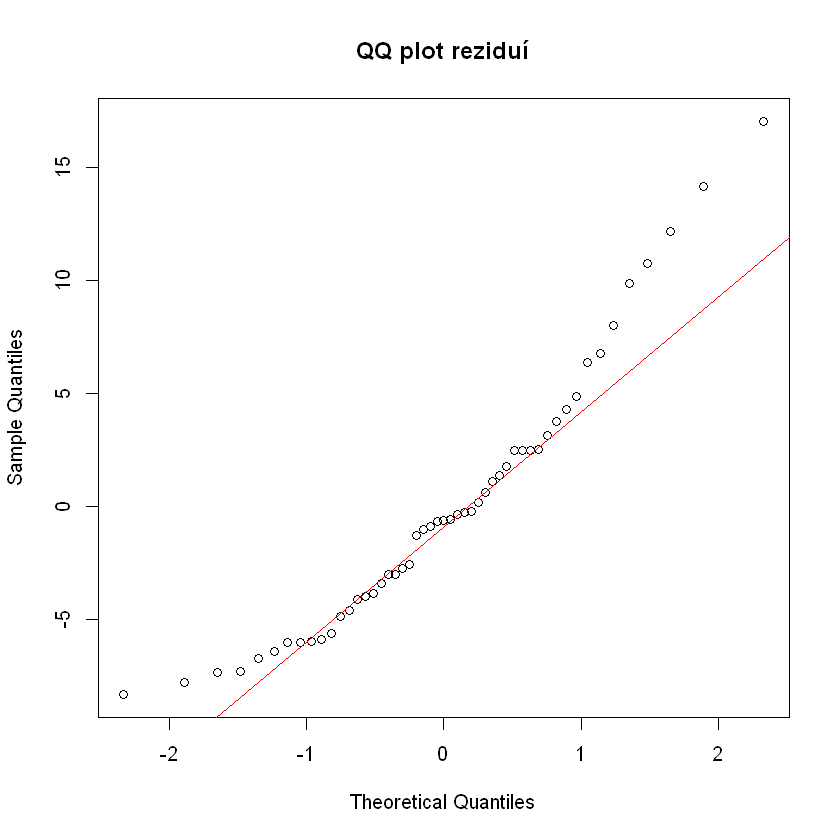

In [7]:
# Kolmogorov-Smirnov test normality reziduí
# H0: rezídua pochádzajú z normálneho rozdelenia
# H1: rezídua nepochádzajú z normálneho rozdelenia

epsilonHAT <- resid(model)

ks <- ks.test(epsilonHAT, "pnorm", mean = 0, sd = sqrt(var(epsilonHAT)))

cat("=== KS TEST NORMALITY ===\n")
cat("Statistika D:", round(ks$statistic, 4), "\n")
cat("p-hodnota:  ", round(ks$p.value, 4), "\n")
cat("Záver:", ifelse(ks$p.value < 0.05,
  "ZAMIETAME H0 — rezídua nie sú normálne rozdelené.",
  "NEZAMIETAME H0 — rezídua sú kompatibilné s normálnym rozdelením."), "\n")

# QQ plot
qqnorm(epsilonHAT, main = "QQ plot reziduí")
qqline(epsilonHAT, col = "red")